In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
from MDAnalysis.analysis import dihedrals

v1s[0][0]

v1_dihedrals=[]
for i in range(len(v1s)):
    sub=[]
    for j in range(len(v1s[i])):
        rama = dihedrals.Ramachandran(v1s[i][j]).run()
        sub.append(rama.angles)
    v1_dihedrals.append(sub)


In [ ]:
figure(figsize = (20,20))
scatter(rama.angles[:,:,0].flatten(),rama.angles[:,:,1].flatten(),alpha = 0.5)

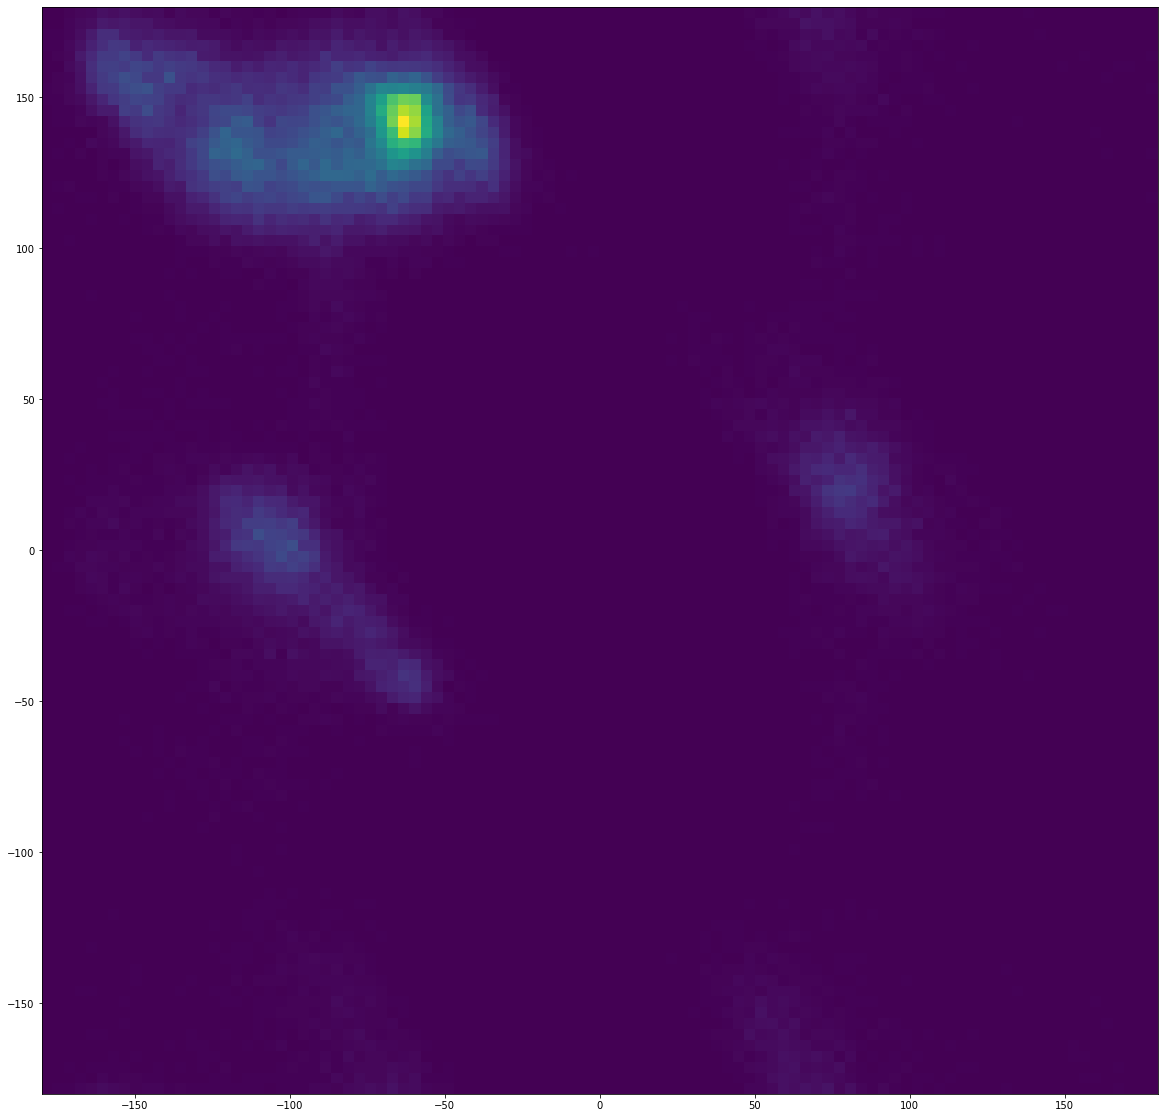

In [33]:
figure(figsize = (20,20))
_=hist2d(rama.angles[:,:,0].flatten(),rama.angles[:,:,1].flatten(),bins = 100)

In [35]:


shaped_dists=[]
pca_colours = []
for i in range(len(v1_dihedrals)):
    for j in range(len(v1_dihedrals[i])):
        for k in range(len(v1_dihedrals[i][j].reshape(4001,-1))):
            shaped_dists.append(v1_dihedrals[i][j].reshape(4001,-1)[k])
            pca_colours.append(colourScheme[i])



Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)


In [ ]:
#import UMAP
import umap

# do UMAP with various parameters
many_n_neighbors = list(arange(4,60,2))
many_min_dist = list(arange(.1,1,0.05))


#n_neighbors=2
#min_dist=.01
for i in range(len(many_n_neighbors)):
    for j in range(len(many_min_dist)):
        n_neighbors = int(many_n_neighbors[i])
        min_dist = float(many_min_dist[j])

        reducer = umap.UMAP(n_neighbors=n_neighbors,
                                    min_dist=min_dist,
                                    transform_seed = 1,
                                    random_state = 1)
        
        embedding = reducer.fit_transform(Z)

        figure(figsize = (12,12))
        scatter(*embedding.T,color = pca_colours,alpha = 0.1)
        title("UMAP on PCA structures with n_neighbours="+str(n_neighbors)+" and min_dist="+str(min_dist))
        savefig("umap_animation-dihedrals/n_neighbours="+str(n_neighbors)+"_min_dist="+str(min_dist)+".png")

<ipython-input-36-3f725a289134>:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  figure(figsize = (12,12))
